In [1]:
import torch
from matplotlib import pyplot as plt
from torch_scattering import multislice, interaction_parameter, transmission_function


# Build a 3D scattering potential containing a few Gaussian blobs

In [2]:
N_XY = 64
N_Z = 512
PIXEL_SIZE = 1.0  # Angstrom
ENERGY = 300.0  # keV

BLOBS = [
    {"center": (10, 32, 27), "sigma": 2.0, "amplitude": 100},
    {"center": (10, 32, 37), "sigma": 2.0, "amplitude": 100.},
]

In [3]:
def gaussian_blob(
    coords: torch.Tensor, center: tuple[float, float, float], sigma: float, amplitude: float
) -> torch.Tensor:
    """Evaluate an isotropic 3D Gaussian at each point in `coords`."""
    r2 = ((coords - torch.tensor(center)) ** 2).sum(dim=-1)
    return amplitude * torch.exp(-r2 / (2 * sigma**2))

In [4]:
zz, yy, xx = torch.meshgrid(
    torch.arange(N_Z), torch.arange(N_XY), torch.arange(N_XY), indexing="ij"
)
coords = torch.stack([zz, yy, xx], dim=-1).float()

potential = torch.zeros(N_Z, N_XY, N_XY)
for blob in BLOBS:
    potential += gaussian_blob(coords, **blob)

# multislice expects a complex-valued potential, batched as (B, Z, Y, X)
potential = potential.to(torch.complex64)[None]
potential.shape

torch.Size([1, 512, 64, 64])

take a look at the central z-slice of the potential we just built

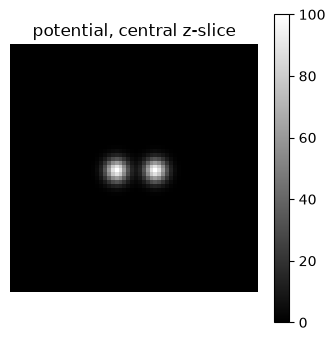

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(potential[0, 10].real, cmap="gray")
ax.set_title("potential, central z-slice")
ax.axis("off")
fig.colorbar(im, ax=ax)
plt.show()

run multislice to get the 2D exit wave

In [6]:
exit_wave = multislice(potential, pixel_size=PIXEL_SIZE, energy=ENERGY)
exit_wave.shape

torch.Size([1, 64, 64])

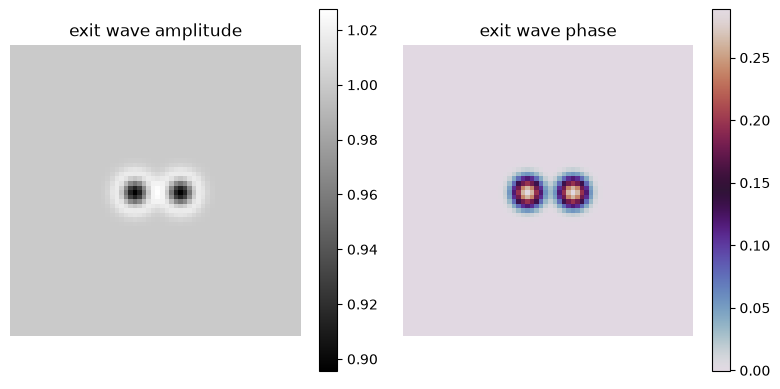

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im0 = axes[0].imshow(exit_wave[0].abs(), cmap="gray")
axes[0].set_title("exit wave amplitude")
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(exit_wave[0].angle(), cmap="twilight")
axes[1].set_title("exit wave phase")
fig.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Compare against the projection approximation, which ignores propagation between slices: `psi = exp(i * sigma * sum_z(V(z)))`

In [8]:

sigma = interaction_parameter(energy=ENERGY)
projected_potential = potential.sum(dim=1)  # sum over Z -> (B, Y, X)
projection_wave = transmission_function(projected_potential, sigma=sigma, dz=PIXEL_SIZE)
projection_wave.shape

torch.Size([1, 64, 64])

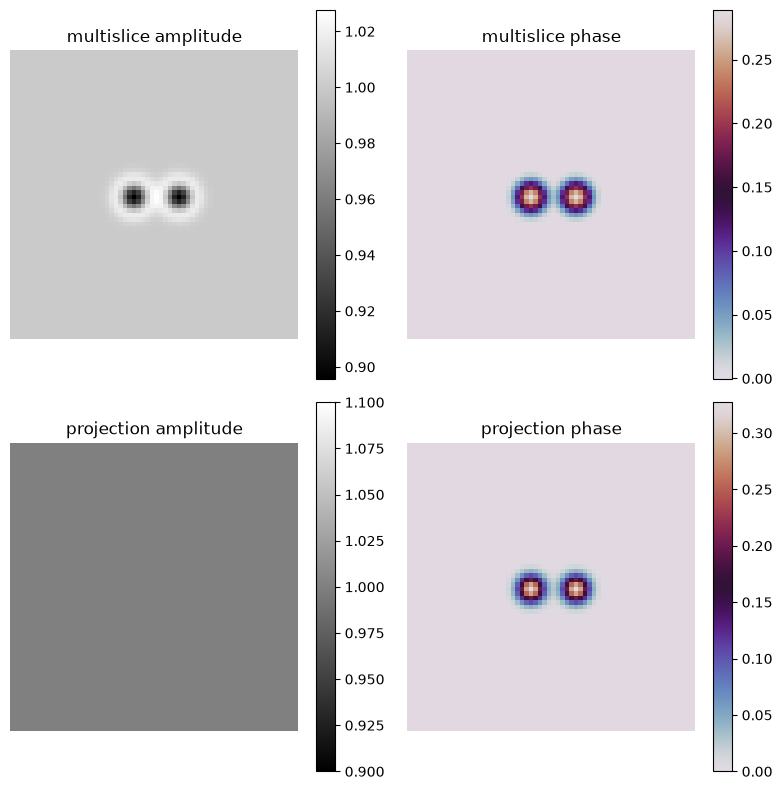

max |phase difference| = 0.0383 rad


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
im00 = axes[0, 0].imshow(exit_wave[0].abs(), cmap="gray")
axes[0, 0].set_title("multislice amplitude")
fig.colorbar(im00, ax=axes[0, 0])
im01 = axes[0, 1].imshow(exit_wave[0].angle(), cmap="twilight")
axes[0, 1].set_title("multislice phase")
fig.colorbar(im01, ax=axes[0, 1])
im10 = axes[1, 0].imshow(projection_wave[0].abs(), cmap="gray")
axes[1, 0].set_title("projection amplitude")
fig.colorbar(im10, ax=axes[1, 0])
im11 = axes[1, 1].imshow(projection_wave[0].angle(), cmap="twilight")
axes[1, 1].set_title("projection phase")
fig.colorbar(im11, ax=axes[1, 1])
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

phase_diff = (exit_wave[0].angle() - projection_wave[0].angle()).abs()
print(f"max |phase difference| = {phase_diff.max():.4f} rad")

## Effect of `n_slices` on the exit wave

coarser grouping (`n_slices` well below the full 512 z-slices) trades multislice accuracy for speed. compare the exit wave amplitude and phase across several settings, using the full-resolution result (`exit_wave` above) as the reference.

In [10]:
N_SLICES_VALUES = [64, 32, 16, 8, 4, 2, 1]

waves_by_n_slices = {
    n: multislice(potential, pixel_size=PIXEL_SIZE, energy=ENERGY, n_slices=n)
    for n in N_SLICES_VALUES
}

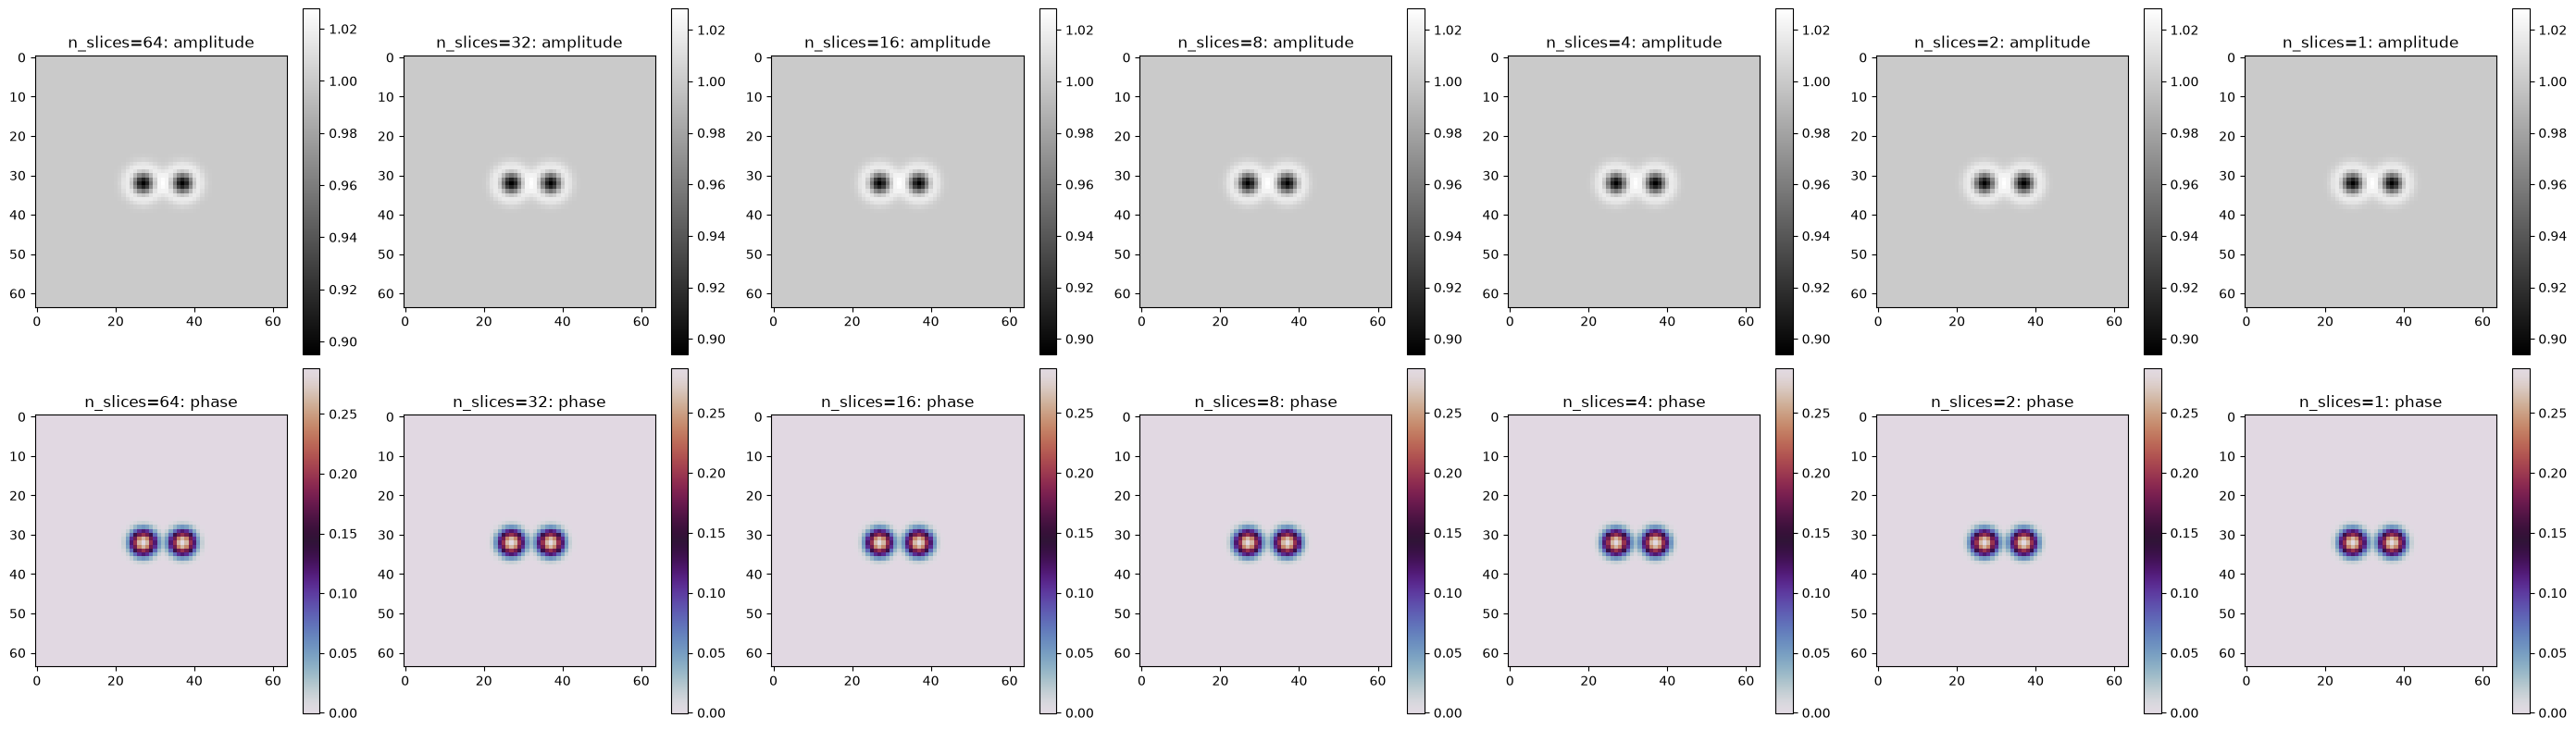

In [13]:
fig, axes = plt.subplots(2, len(N_SLICES_VALUES), figsize=(4 * len(N_SLICES_VALUES), 8))
for col, n in enumerate(N_SLICES_VALUES):
    wave = waves_by_n_slices[n]
    im_amp = axes[0, col].imshow(wave[0].abs(), cmap="gray")
    axes[0, col].set_title(f"n_slices={n}: amplitude")
    fig.colorbar(im_amp, ax=axes[0, col])
    im_phase = axes[1, col].imshow(wave[0].angle(), cmap="twilight")
    axes[1, col].set_title(f"n_slices={n}: phase")
    fig.colorbar(im_phase, ax=axes[1, col])
plt.tight_layout()
plt.show()

In [12]:
print(f"{'n_slices':>10} {'max |amp diff|':>16} {'max |phase diff|':>18}")
for n in N_SLICES_VALUES:
    wave = waves_by_n_slices[n]
    amp_diff = (wave[0].abs() - exit_wave[0].abs()).abs().max()
    phase_diff = (wave[0].angle() - exit_wave[0].angle()).abs().max()
    print(f"{n:>10} {amp_diff:>16.4f} {phase_diff:>18.4f}")

  n_slices   max |amp diff|   max |phase diff|
        64           0.0004             0.0004
        32           0.0015             0.0013
        16           0.0015             0.0013
         8           0.0015             0.0013
         4           0.0015             0.0013
         2           0.0015             0.0013
         1           0.0015             0.0013
